**Amira Shlebik**  
**Heartbeat Classification using Electrocardiogram (ECG) Signals**  

---

## Table of Contents

- [1. Introduction](#sec-1)
- [2. Exploratory Data Analysis (EDA)](#sec-2)
  - [2.1 Class Distribution](#sec-2-1)
  - [2.2 ECG Signal Visualisation](#sec-2-2)
  - [2.3 Data Quality Checks](#sec-2-3)
  - [2.4 EDA Implications](#sec-2-4)
- [3. Preprocessing and Splitting Strategy](#sec-3)
  - [3.1 Removing Duplicates](#sec-3-1)
  - [3.2 MIT-BIH Split](#sec-3-2)
  - [3.3 PTB: Random Split](#sec-3-3)
  - [3.4 PTB: Cluster-based Split](#sec-3-4)
  - [3.5 Class Weights](#sec-3-5)
- [4. Model Selection and Design](#sec-4)
  - [4.1 Why 1D CNN](#sec-4-1)
  - [4.2 CNN Architecture](#sec-4-2)
  - [4.3 Baseline Models](#sec-4-3)
- [5. Model Training and Hyperparameter Tuning](#sec-5)
  - [5.1 CNN Training Configuration](#sec-5-1)
  - [5.2 MIT-BIH Training](#sec-5-2)
  - [5.3 PTB Training](#sec-5-3)
  - [5.4 CNN Hyperparameter Tuning](#sec-5-4)
  - [5.5 Logistic Regression Tuning](#sec-5-5)
  - [5.6 Random Forest Tuning](#sec-5-6)
- [6. Evaluation and Comparison](#sec-6)
  - [6.1 Classification Reports](#sec-6-1)
  - [6.2 Confusion Matrices](#sec-6-2)
  - [6.3 ROC Curves and AUC](#sec-6-3)
  - [6.4 Summary Comparison Table](#sec-6-4)
- [7. Critical Evaluation and Reflection](#sec-7)
  - [7.1 Strengths and Limitations](#sec-7-1)
  - [7.2 Challenges Encountered](#sec-7-2)
  - [7.3 Proposed Improvements](#sec-7-3)
- [8. Conclusion](#sec-8)
- [9. References](#sec-9)



<a id="sec-1"></a>
## 1. Introduction
Cardiovascular disease remains one of the leading causes of death worldwide, making accurate and timely cardiac diagnosis essential. Electrocardiograms (ECGs) are widely used to monitor heart activity, but manual interpretation by specialists is time-consuming and resource-intensive. Deep learning provides a scalable alternative by enabling automated ECG classification that can support clinical decision-making.  

This project addresses two ECG heartbeat classification tasks using PhysioNet datasets preprocessed by Kachuee et al. (2018). Heartbeats were segmented, resampled to 125Hz, and padded to a fixed length of 187 timesteps.

The first dataset, MIT-BIH Arrhythmia Database, contains 109,446 annotated beats from 47 subjects. The second dataset, PTB Diagnostic ECG Database, contains 14,552 records from 290 subjects covering multiple cardiac conditions.  

Two classification tasks are investigated:  
•	MIT-BIH: 5-class classification of Normal (N), Supraventricular (S), Ventricular (V), Fusion (F), and Unclassifiable (Q) beats.  
•	PTB: Binary classification of Normal versus Abnormal heartbeats.

In [1]:
!pip install kneed -q

In [2]:
# Setup & Imports
import os

#  Standard libraries 
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Third-party libraries
import matplotlib.pyplot as plt      # for plotting
import numpy as np                   # for numerical operations
import pandas as pd                  # for data manipulation
import seaborn as sns                # more sophisticated plots
from kneed import KneeLocator

#  Machine learning 
from sklearn.cluster import MiniBatchKMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    auc, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, average_precision_score
)
from sklearn.model_selection import train_test_split, GroupShuffleSplit, cross_val_score
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.cluster import MiniBatchKMeans
from sklearn.linear_model import LogisticRegression

#  Deep learning 
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, SpatialDropout1D
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2

# Configuration & Reproducibility
# We set a fixed seed for both NumPy and TensorFlow to ensure reproducibility for this notebook
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Global variables
colors = ['#4CAF50','#E91E63','#FF9800','#9C27B0','#2196F3']
TIMESTEPS = 187
class_names_mit = ['Normal (N)', 'Atrial Premature (S)', 'Ventricular (V)', 'Fusion (F)', 'Unclassifiable (Q)']
mit_labels = ['N', 'S', 'V', 'F', 'Q']
class_names_ptb = ['Normal', 'Abnormal']

print('All imports successful!')

E0000 00:00:1778446934.031785    2657 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778446934.039498    2657 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778446934.057874    2657 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778446934.057894    2657 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778446934.057896    2657 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778446934.057898    2657 computation_placer.cc:177] computation placer already registered. Please check linka

All imports successful!


<a id="sec-2"></a>
## 2. Exploratory Data Analysis (EDA)
EDA was conducted to understand dataset structure, identify class imbalance, and inspect signal quality before model training.

In [3]:
# Data Loading
"""The four dataset files (mitbih_train.csv, mitbih_test.csv, ptbdb_normal.csv, ptbdb_abnormal.csv) 
have been downloaded from Kaggle and placed in the same directory as this notebook. 
No file paths are required, all files are loaded using their filenames directly."
"""
# MIT: 5-class problem
# my laptop
# mit_train = pd.read_csv("mitbih_train.csv", header=None)
# mit_test  = pd.read_csv("mitbih_test.csv",  header=None)

# Kaggle
mit_train   = pd.read_csv("/kaggle/input/datasets/shayanfazeli/heartbeat/mitbih_train.csv",  header=None)
mit_test = pd.read_csv("/kaggle/input/datasets/shayanfazeli/heartbeat/mitbih_test.csv", header=None)

X_mit_train = mit_train.iloc[:, :187].values
y_mit_train = mit_train.iloc[:, 187].values.astype(int)
X_mit_test  = mit_test.iloc[:, :187].values
y_mit_test  = mit_test.iloc[:, 187].values.astype(int)

# we combine train and test stes to visualise the full class distribution (only for EDA not for model training)
X_mit = np.concatenate([X_mit_train,X_mit_test])
y_mit = np.concatenate([y_mit_train, y_mit_test])

# PTB: binary classification
# my laptop
# ptb_normal   = pd.read_csv("ptbdb_normal.csv",   header=None)
# ptb_abnormal = pd.read_csv("ptbdb_abnormal.csv", header=None)

# Kaggle
ptb_normal   = pd.read_csv("/kaggle/input/datasets/shayanfazeli/heartbeat/ptbdb_normal.csv",   header=None)
ptb_abnormal = pd.read_csv("/kaggle/input/datasets/shayanfazeli/heartbeat/ptbdb_abnormal.csv", header=None)

# The two files were stacked in order: all normal first, then all abnormal
ptb_all = pd.concat([ptb_normal, ptb_abnormal], ignore_index=True)

X_ptb = ptb_all.iloc[:, :187].values
y_ptb = ptb_all.iloc[:, 187].values.astype(int)
# The raw CSV files have inverted labels: ptbdb_normal.csv contains label 0 but holds
# only 4,045 samples, while ptbdb_abnormal.csv contains label 1 but holds 10,500 samples.
# This is inconsistent with the known dataset distribution where Normal is the majority
# and Abnormal is the minority. We therefore flip the labels so that Normal=0 and Abnormal=1
# correctly reflect the true class identity.
y_ptb = np.where(y_ptb == 0, 1, 0)

# We shuffle to mix them up before splitting, to ensure each split contains both classes
# permutation generates a randomly ordered list of row indices from 0 to len(X_ptb)-1, which we use to reorder the data
idx = np.random.permutation(len(X_ptb))
# reorder both X and y the same way so each row still matches its label
X_ptb, y_ptb = X_ptb[idx], y_ptb[idx]

In [4]:
print("Normal file label:", ptb_normal.iloc[:, 187].unique())
print("Abnormal file label:", ptb_abnormal.iloc[:, 187].unique())
print("Class counts in y_ptb:", np.unique(y_ptb, return_counts=True))

Normal file label: [0.]
Abnormal file label: [1.]
Class counts in y_ptb: (array([0, 1]), array([10506,  4046]))


<a id="sec-2-1"></a>
### 2.1 Class Distribution
**Both datasets** are **class-imbalanced** (MIT-BIH: 82.8% Normal, 0.7% Fusion; PTB: 72.2% Normal), making accuracy a misleading metric. **AUC-PR is the primary** evaluation **metric**.

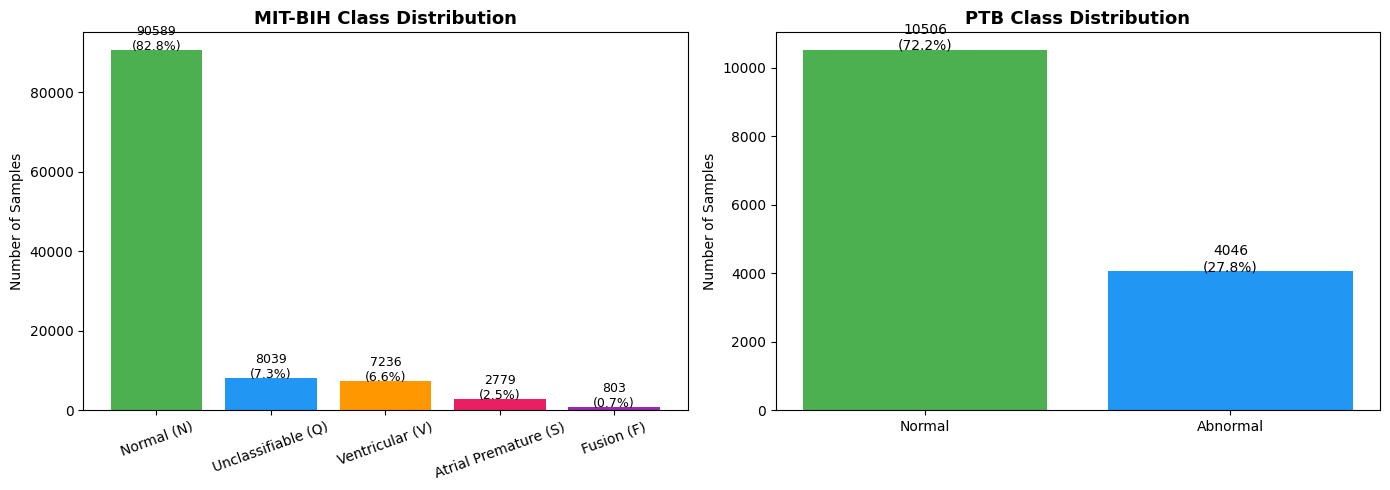

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MIT class counts
# Sort by count descending
unique_mit, counts_mit = np.unique(y_mit, return_counts=True)

sorted_idx = np.argsort(counts_mit)[::-1]
sorted_names = [class_names_mit[i] for i in sorted_idx]
sorted_counts = counts_mit[sorted_idx]
sorted_colors = [colors[i] for i in sorted_idx]

# np.unique returns the unique class labels and their counts
unique_mit, counts_mit = np.unique(y_mit, return_counts=True)
axes[0].bar(sorted_names, sorted_counts, color=sorted_colors)
axes[0].set_title('MIT-BIH Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Samples')
axes[0].tick_params(axis='x', rotation=20)
for i, (count, pct) in enumerate(zip(sorted_counts, sorted_counts/len(y_mit)*100)):
    axes[0].text(i, count + 30, f'{count}\n({pct:.1f}%)', ha='center', fontsize=9)

# PTB class counts
unique_ptb, counts_ptb = np.unique(y_ptb, return_counts=True)
#unique_ptb, counts_ptb = unique_ptb[::-1], counts_ptb[::-1] # it's only 2-classes, so we can just reverse these two arrays
axes[1].bar(class_names_ptb, counts_ptb, color= [colors[0], colors[4]])
axes[1].set_title('PTB Class Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Number of Samples')
for i, (count, pct) in enumerate(zip(counts_ptb, counts_ptb/len(y_ptb)*100)):
    axes[1].text(i, count + 10, f'{count}\n({pct:.1f}%)', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

<a id="sec-2-2"></a>
### 2.2 ECG Signal Visualisation
**MIT classes showed distinct waveform structures**:  
- **N** beats were the **most consistent**.
- **S** beats showed **high variability**, making them difficult to learn.
- **V** beats displayed **irregular** fluctuations before sharp peaks.
- **F** beats **combined** characteristics of **N and V classes**, increasing ambiguity.
- **Q** beats showed surprisingly **consistent** patterns **despite** being labelled **unclassifiable**.

**PTB** Normal and Abnormal signals were **structurally similar**, although abnormal signals showed greater irregularity before the main spike.
**Both datasets** also **showed cut-off peaks at timestep 0**, indicating segmentation artefacts caused by windows beginning mid-beat.

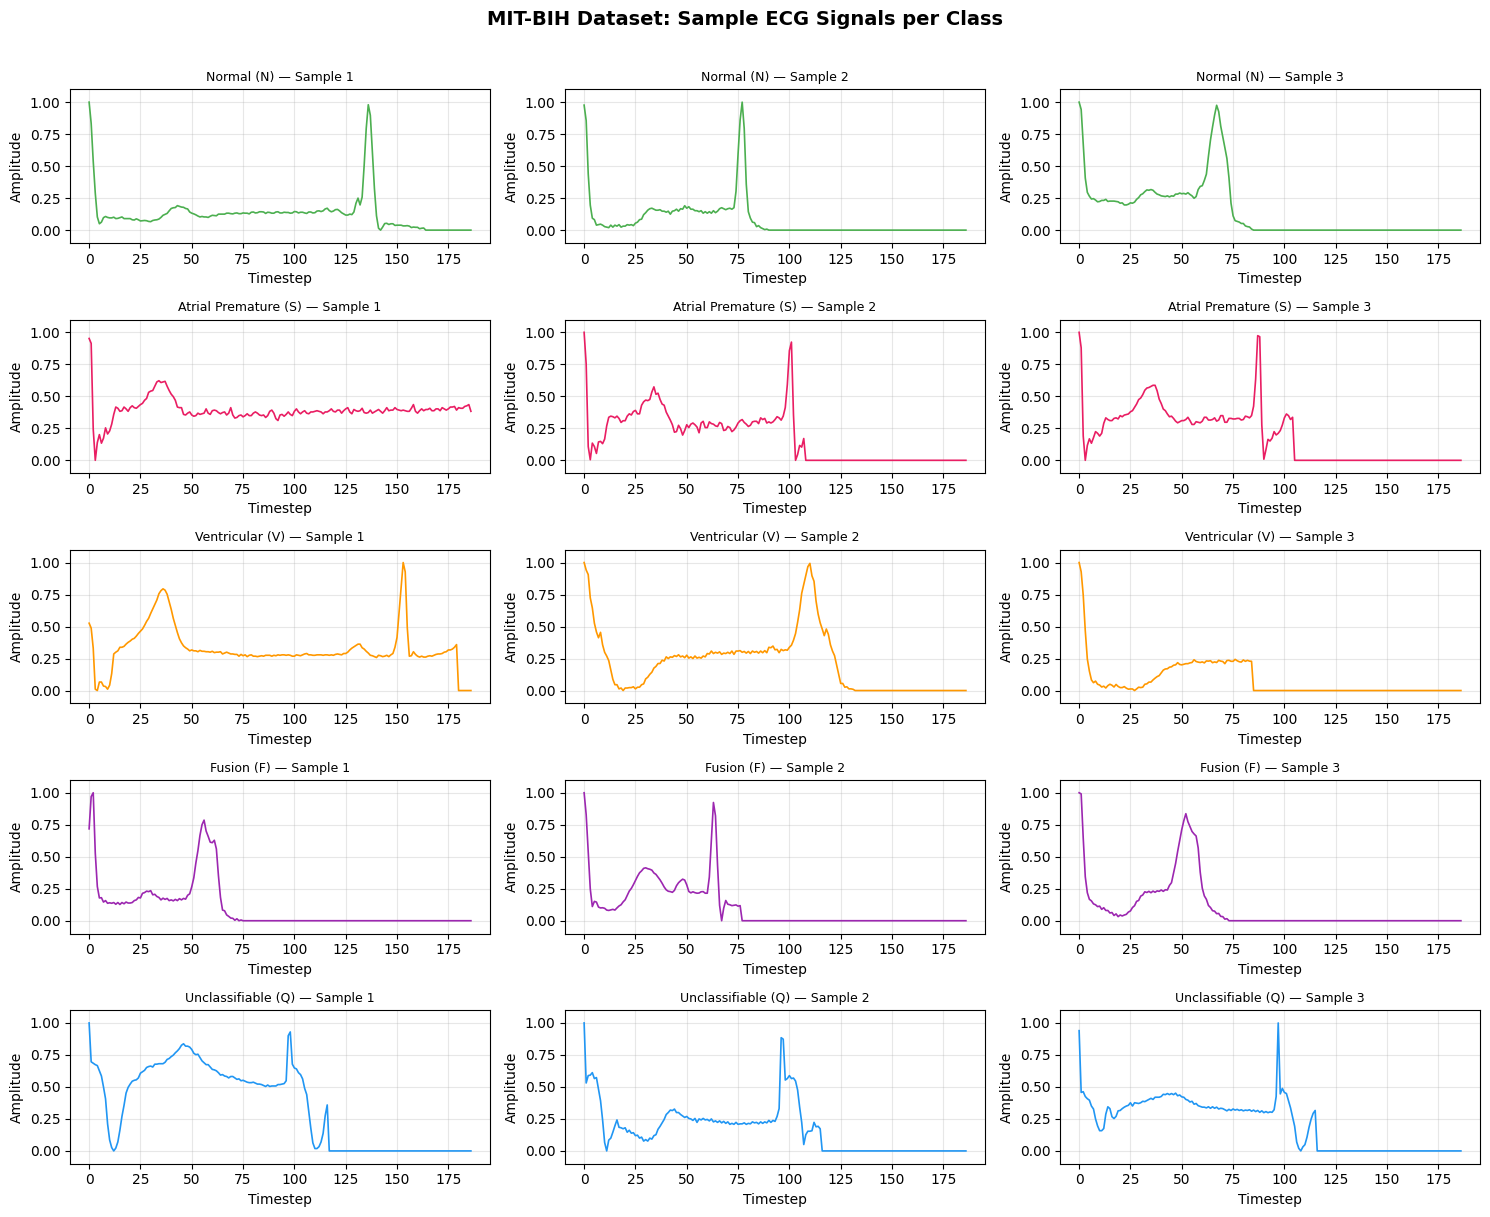

In [6]:
"""
Three random heartbeat signals are plotted for each class in the two datasets to visually 
compare waveform shapes and build intuition about what distinguishes one class from another. 
This also serves as a sanity check that the data loaded and labelled correctly, 
if all classes looked identical, that would be a red flag!
"""
# MIT 5-Class Visualization
fig, axes = plt.subplots(5, 3, figsize=(15, 12))

for class_idx in range(5): # ['N': 0, 'S': 1, 'V': 2, 'F': 3, 'Q': 4]
    # Get 3 random samples from this class
    class_samples = X_mit[y_mit == class_idx]
    np.random.seed(SEED + class_idx) # each class gets a reproducible set of samples every run
    sample_indices = np.random.choice(len(class_samples), 3, replace=False)
    
    for col, sample_idx in enumerate(sample_indices):
        ax = axes[class_idx, col]
        ax.plot(class_samples[sample_idx], color=colors[class_idx], linewidth=1.2)
        ax.set_title(f'{class_names_mit[class_idx]} — Sample {col+1}', fontsize=9)
        ax.set_xlabel('Timestep')
        ax.set_ylabel('Amplitude')
        ax.set_ylim(-0.1, 1.1)
        ax.grid(True, alpha=0.3)

plt.suptitle('MIT-BIH Dataset: Sample ECG Signals per Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('MIT_signal_visualisation.png', dpi=120, bbox_inches='tight')
plt.show()

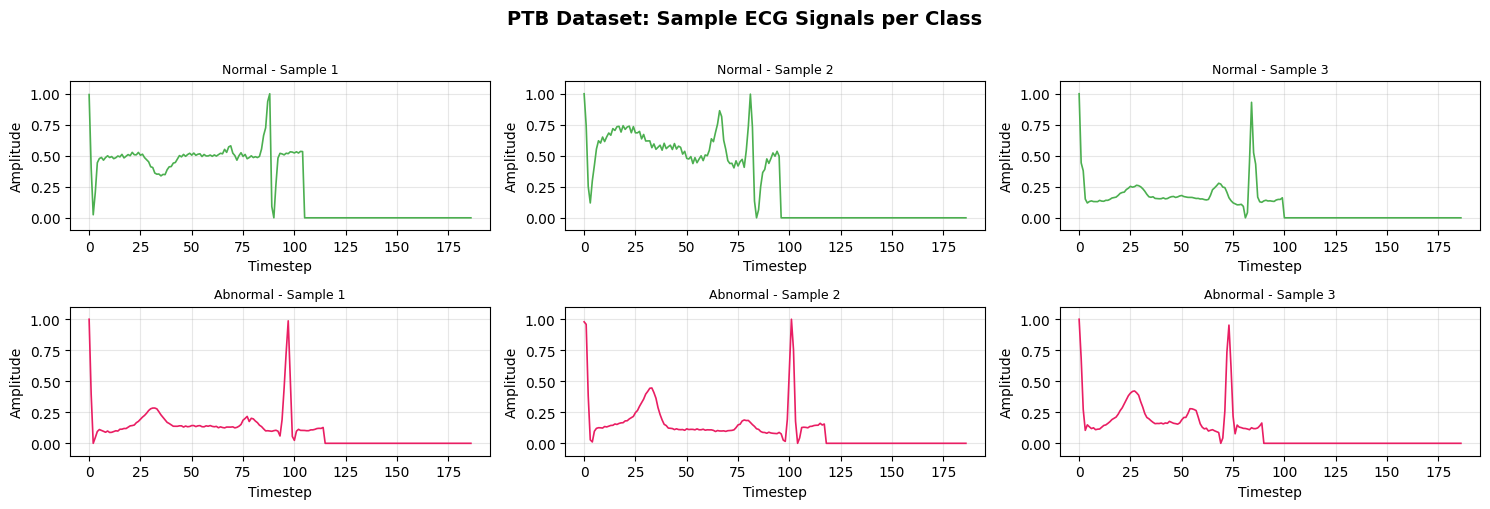

In [7]:
# PTB 2-Class Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 5))
 
for class_idx in range(2): # Classes: ['Normal': 0, 'Abnormal': 1]
    # Get 3 random samples from this class
    class_samples = X_ptb[y_ptb == class_idx]
    np.random.seed(SEED + class_idx)
    sample_indices = np.random.choice(len(class_samples), 3, replace=False)
    
    for col, sample_idx in enumerate(sample_indices):
        ax = axes[class_idx, col]
        ax.plot(class_samples[sample_idx], color=colors[class_idx], linewidth=1.2)
        ax.set_title(f'{class_names_ptb[class_idx]} - Sample {col+1}', fontsize=9)
        ax.set_xlabel('Timestep')
        ax.set_ylabel('Amplitude')
        ax.set_ylim(-0.1, 1.1)
        ax.grid(True, alpha=0.3)

plt.suptitle('PTB Dataset: Sample ECG Signals per Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('ptb_signal_visualisation.png', dpi=120, bbox_inches='tight')
plt.show()


<a id="sec-2-3"></a>
### 2.3 Data Quality Checks
Both datasets are **clean; no missing data, no out-of-range values**, and already **normalised to [0, 1]. MIT-BIH** was **duplicate-free**, while PTB had a few.

In [8]:
"""
A quality check is performed on both datasets to verify data integrity before preprocessing, 
checking for missing values, duplicate rows, and confirming the expected value range.
"""
# MIT Data Inspection
df_mit = pd.DataFrame(X_mit, columns=[f't{i}' for i in range(TIMESTEPS)])
df_mit['label'] = y_mit.astype(int)

print('MIT DataFrame')
print(f'Shape: {df_mit.shape}  →  {df_mit.shape[0]} rows (samples), {df_mit.shape[1]} columns (187 features + 1 label)')
print()
print('First 3 rows (showing only first 5 timestep columns + label):')
print(df_mit[['t0','t1','t2','t3','t4','label']].head(3))
print()
print(f'Missing values: {df_mit.isnull().sum().sum()}')
print(f'Duplicate rows: {df_mit.duplicated().sum()}')
print()
print('Value range check (first 5 features):')
print(df_mit[['t0','t1','t2','t3','t4']].describe().loc[['min','max','mean']])
print()


MIT DataFrame
Shape: (109446, 188)  →  109446 rows (samples), 188 columns (187 features + 1 label)

First 3 rows (showing only first 5 timestep columns + label):
         t0        t1        t2        t3        t4  label
0  0.977941  0.926471  0.681373  0.245098  0.154412      0
1  0.960114  0.863248  0.461538  0.196581  0.094017      0
2  1.000000  0.659459  0.186486  0.070270  0.070270      0

Missing values: 0
Duplicate rows: 0

Value range check (first 5 features):
           t0        t1        t2        t3        t4
min   0.00000  0.000000  0.000000  0.000000  0.000000
max   1.00000  1.000000  1.000000  1.000000  1.000000
mean  0.89117  0.758909  0.424503  0.219602  0.201237



In [9]:
# PTB Data Inspection
df_ptb = pd.DataFrame(X_ptb, columns=[f't{i}' for i in range(TIMESTEPS)])
df_ptb['label'] = y_ptb.astype(int)

print('PTB DataFrame')
print(f'Shape: {df_ptb.shape}  →  {df_ptb.shape[0]} rows (samples), {df_ptb.shape[1]} columns (187 features + 1 label)')
print()
print('First 3 rows (showing only first 5 timestep columns + label):')
print(df_ptb[['t0','t1','t2','t3','t4','label']].head(3))
print()
print(f'Missing values: {df_ptb.isnull().sum().sum()}')
print(f'Duplicate rows: {df_ptb.duplicated().sum()}')
print()
print('Value range check (first 5 features):')
print(df_ptb[['t0','t1','t2','t3','t4']].describe().loc[['min','max','mean']])
print()


PTB DataFrame
Shape: (14552, 188)  →  14552 rows (samples), 188 columns (187 features + 1 label)

First 3 rows (showing only first 5 timestep columns + label):
         t0        t1        t2        t3        t4  label
0  1.000000  0.866995  0.282841  0.059934  0.083333      1
1  0.983679  0.655367  0.492153  0.052731  0.003139      0
2  0.888675  1.000000  0.863636  0.644838  0.430663      0

Missing values: 0
Duplicate rows: 7

Value range check (first 5 features):
            t0        t1        t2        t3        t4
min   0.624227  0.000000  0.000000  0.000000  0.000000
max   1.000000  1.000000  1.000000  1.000000  1.000000
mean  0.976637  0.721663  0.403099  0.242893  0.207218



<a id="sec-2-4"></a>
### 2.4 EDA Implications

The EDA showed several important issues:
<div style="text-align: left;width: 100%">
    
| Issue | Proposed Action |
|:---|:---|
| Heavy class imbalance (MIT-BIH 82.8% Normal, PTB 72.2% Normal) | Apply class weights during training to penalise minority class misclassification; avoid relying on accuracy alone |
| Within-class signal variation, especially Class S (2.5% representation) | Expected underperformance on Class S; should be reflected in evaluation |
| Cut-off peaks at timestep 0 across all classes | No intervention; artefacts are consistent and the 1D CNN should handle them inherently |
|PTB contained seven duplicate records | To be removed during preprocessing |
    
</div>

<a id="sec-3"></a>
## 3. Preprocessing and Splitting Strategy  
Since the datasets were already normalised, preprocessing focused mainly on handling duplicates, imbalance and designing reliable train-validation-test splits.

<a id="sec-3-1"></a>
### 3.1 Removing Duplicates

In [10]:
dup = df_ptb.duplicated().sum()

df_ptb = df_ptb.drop_duplicates()

if(df_ptb.duplicated().sum() > 0):
    print("PTB data still has duplicates")
else:
    X_ptb = df_ptb.iloc[:, :187].values
    y_ptb = df_ptb['label'].values
    print(f"{dup} duplicates removed from PTB, leaving {df_ptb.shape[0]} samples")

7 duplicates removed from PTB, leaving 14545 samples


<a id="sec-3-2"></a>
### 3.2 MIT-BIH Split
The Kaggle train/test split was preserved. A stratified 15% validation set was carved from training data for EarlyStopping; the Kaggle test set is used only for final evaluation.

In [11]:
X_mit_train, X_mit_val, y_mit_train, y_mit_val = train_test_split(
    X_mit_train, y_mit_train, test_size=0.15, random_state=SEED, stratify=y_mit_train
)

<a id="sec-3-3"></a>
### 3.3 PTB: Random Split
A baseline random split of 70/15/15 was created using stratification to preserve class proportions. 

In [12]:
# Split data by 70% train, 30% val_test
# stratify=y_ptb ensures each split preserves the original class ratio (72% Normal / 28% Abnormal)
# Without stratification, a random split could produce imbalanced subsets by chance

X_ptb_train_r, X_ptb_val_test_r, y_ptb_train_r, y_ptb_val_test_r = train_test_split(
    X_ptb, y_ptb, test_size=0.30, random_state=SEED, stratify=y_ptb
)

# Split the 30% val_test equally into 15% val and 15% test
# stratify is utilized here as well
X_ptb_val_r, X_ptb_test_r, y_ptb_val_r, y_ptb_test_r = train_test_split(
    X_ptb_val_test_r, y_ptb_val_test_r, test_size=0.50, random_state=SEED, stratify=y_ptb_val_test_r
)

print(f'Train : {X_ptb_train_r.shape[0]} samples')
print(f'Val   : {X_ptb_val_r.shape[0]} samples')
print(f'Test  : {X_ptb_test_r.shape[0]} samples')

Train : 10181 samples
Val   : 2182 samples
Test  : 2182 samples


<a id="sec-3-4"></a>
### 3.4 PTB: Cluster-based Split

PTB lacks patient IDs, so a random split risks placing beats from the same patient in both train and test sets. MiniBatchKMeans with 290 clusters (matching the known patient count) was used as a proxy for patient groups, with GroupShuffleSplit separating clusters across splits. Seed 21 produced the best class balance (0.3% gap) and was selected despite the slight deviation from the target 70/15/15, yielding a 68.6/13.6/17.8 split.

In [13]:
# Fit once outside the loop
kmeans = MiniBatchKMeans(n_clusters=290, random_state=SEED, n_init=10)
cluster_ids = kmeans.fit_predict(X_ptb)

best_seed, best_gap, best_result = None, float('inf'), None
 
for seed_try in range(0, 200):       
    gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=seed_try)
    trainval_idx, test_idx = next(gss.split(X_ptb, y_ptb, groups=cluster_ids))
    
    # From the remaining 85%, we cut out 15% for the valudation set -> (0.15/0.85 ≈ 0.176)
    gss_val = GroupShuffleSplit(n_splits=1, test_size=0.176, random_state=seed_try)
    train_idx, val_idx = next(gss_val.split(
        X_ptb[trainval_idx], y_ptb[trainval_idx], groups=cluster_ids[trainval_idx]
    ))
    
    y_tr = y_ptb[trainval_idx][train_idx]
    y_v  = y_ptb[trainval_idx][val_idx]
    y_te = y_ptb[test_idx]
    
    tr_pct  = (y_tr == 0).sum() / len(y_tr) * 100
    val_pct = (y_v  == 0).sum() / len(y_v)  * 100
    te_pct  = (y_te == 0).sum() / len(y_te) * 100
    max_gap = max(tr_pct, val_pct, te_pct) - min(tr_pct, val_pct, te_pct)
    
    if max_gap < best_gap:
        best_gap = max_gap
        best_seed = seed_try
        best_result = (tr_pct, val_pct, te_pct)
    
print(f'Best seed={best_seed} | Train: {best_result[0]:.1f}%  Val: {best_result[1]:.1f}%  Test: {best_result[2]:.1f}%  | gap={best_gap:.1f}%')

# Apply the best seed to produce the final cluster-based split

# Cut out the test set (15% of total), leaving 85% for trainval data
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=best_seed)
trainval_idx, test_idx = next(gss.split(X_ptb, y_ptb, groups=cluster_ids))

# Same here, from the remaining 85%, cut out the validation set
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.176, random_state=best_seed)
train_idx, val_idx = next(gss_val.split(
    X_ptb[trainval_idx], y_ptb[trainval_idx], groups=cluster_ids[trainval_idx]
))

# Assign final split variables
X_ptb_train_c = X_ptb[trainval_idx][train_idx]
y_ptb_train_c = y_ptb[trainval_idx][train_idx]
X_ptb_val_c   = X_ptb[trainval_idx][val_idx]
y_ptb_val_c   = y_ptb[trainval_idx][val_idx]
X_ptb_test_c  = X_ptb[test_idx]
y_ptb_test_c  = y_ptb[test_idx]

# Print split sizes and percentages to verify the ratio
print(f'Train : {X_ptb_train_c.shape[0]} samples ({X_ptb_train_c.shape[0]/len(X_ptb)*100:.1f}%)')
print(f'Val   : {X_ptb_val_c.shape[0]} samples ({X_ptb_val_c.shape[0]/len(X_ptb)*100:.1f}%)')
print(f'Test  : {X_ptb_test_c.shape[0]} samples ({X_ptb_test_c.shape[0]/len(X_ptb)*100:.1f}%)')


# Compare class balance and split sizes between random and cluster-based splits
total = len(y_ptb)

print(f"{'Split':<6} | {'Random':>8} {'%':>6} {'Norm%':>6} {'Abn%':>6} | {'Cluster':>8} {'%':>6} {'Norm%':>6} {'Abn%':>6}")
print('-' * 70)

for split_name, y_r, y_c in [('Train', y_ptb_train_r, y_ptb_train_c),
                               ('Val',   y_ptb_val_r,   y_ptb_val_c),
                               ('Test',  y_ptb_test_r,  y_ptb_test_c)]:
    nr, nc = len(y_r), len(y_c)
    print(f"{split_name:<6} | {nr:>8} {nr/total*100:>5.1f}% {np.sum(y_r==0)/nr*100:>5.1f}% {np.sum(y_r==1)/nr*100:>5.1f}% | "
          f"{nc:>8} {nc/total*100:>5.1f}% {np.sum(y_c==0)/nc*100:>5.1f}% {np.sum(y_c==1)/nc*100:>5.1f}%")

Best seed=21 | Train: 72.2%  Val: 72.1%  Test: 72.3%  | gap=0.3%
Train : 9982 samples (68.6%)
Val   : 1976 samples (13.6%)
Test  : 2587 samples (17.8%)
Split  |   Random      %  Norm%   Abn% |  Cluster      %  Norm%   Abn%
----------------------------------------------------------------------
Train  |    10181  70.0%  72.2%  27.8% |     9982  68.6%  72.2%  27.8%
Val    |     2182  15.0%  72.2%  27.8% |     1976  13.6%  72.1%  27.9%
Test   |     2182  15.0%  72.2%  27.8% |     2587  17.8%  72.3%  27.7%


<a id="sec-3-5"></a>
### 3.5 Class Weights
Class weights were used over oversampling to avoid introducing unrealistic synthetic ECG patterns. Though high weights on rare classes can reduce precision, prioritising recall is more appropriate in a medical context where missing abnormal beats carries greater risk. Weights were calculated from training data; in MIT-BIH, the rare F class (< 1%) received the highest weight, and in PTB, the minority class was similarly up-weighted.

In [14]:
# MIT class weights computed from training labels only
mit_classes = np.unique(y_mit_train)
mit_weights = compute_class_weight(class_weight='balanced', classes=mit_classes, y=y_mit_train)
mit_class_weight_dict = dict(zip(mit_classes, mit_weights))
print('MIT-BIH Class Weights:')
for cls, w in mit_class_weight_dict.items():
    print(f'  Class {cls} ({class_names_mit[cls]}): {w:.4f}')

print()

# PTB class weights computed from cluster split training labels only
ptb_classes = np.unique(y_ptb_train_c)
ptb_weights = compute_class_weight(class_weight='balanced', classes=ptb_classes, y=y_ptb_train_c)
ptb_class_weight_dict = dict(zip(ptb_classes, ptb_weights))
print('PTB Class Weights:')
for cls, w in ptb_class_weight_dict.items():
    print(f'  Class {cls} ({class_names_ptb[cls]}): {w:.4f}')

MIT-BIH Class Weights:
  Class 0 (Normal (N)): 0.2416
  Class 1 (Atrial Premature (S)): 7.8793
  Class 2 (Ventricular (V)): 3.0252
  Class 3 (Fusion (F)): 27.3101
  Class 4 (Unclassifiable (Q)): 2.7230

PTB Class Weights:
  Class 0 (Normal): 0.6927
  Class 1 (Abnormal): 1.7973


<a id="sec-4"></a>
## 4. Model Selection and Design
Three models were evaluated:  
- 1D Convolutional Neural Network
- Logistic Regression
- Random Forest

<a id="sec-4-1"></a>
### 4.1 Why 1D CNN
ECG signals are one-dimensional time series, making 1D CNNs well suited for the task. Convolutional filters slide along the signal and automatically learn local waveform patterns such as peaks and rhythm structures, preserving temporal structure without manual feature engineering. Signals were therefore reshaped from (samples, 187) to (samples, 187, 1) to match the CNN's expected input format.

In [15]:
# Reshape from (samples, 187) to (samples, 187, 1) for 1D CNN input
X_mit_train_cnn = X_mit_train.reshape(-1, TIMESTEPS, 1)
X_mit_val_cnn   = X_mit_val.reshape(-1, TIMESTEPS, 1)
X_mit_test_cnn  = X_mit_test.reshape(-1, TIMESTEPS, 1)

X_ptb_train_cnn = X_ptb_train_c.reshape(-1, TIMESTEPS, 1)
X_ptb_val_cnn   = X_ptb_val_c.reshape(-1, TIMESTEPS, 1)
X_ptb_test_cnn  = X_ptb_test_c.reshape(-1, TIMESTEPS, 1)

print(f'MIT-BIH Train : {X_mit_train_cnn.shape}')
print(f'MIT-BIH Val   : {X_mit_val_cnn.shape}')
print(f'MIT-BIH Test  : {X_mit_test_cnn.shape}')
print(f'PTB Train     : {X_ptb_train_cnn.shape}')
print(f'PTB Val       : {X_ptb_val_cnn.shape}')
print(f'PTB Test      : {X_ptb_test_cnn.shape}')

MIT-BIH Train : (74420, 187, 1)
MIT-BIH Val   : (13134, 187, 1)
MIT-BIH Test  : (21892, 187, 1)
PTB Train     : (9982, 187, 1)
PTB Val       : (1976, 187, 1)
PTB Test      : (2587, 187, 1)


<a id="sec-4-2"></a>
### 4.2 CNN Architecture
A three-block 1D CNN is used, each block containing Conv1D for feature extraction, Batch Normalisation for stable learning, and Max Pooling for dimensionality reduction, progressing from simple waveform shapes in Block 1 to full heartbeat patterns in Block 3.

|Layer|Role|How It Works|
|:-|:-|:-|
| Conv1D | The Pattern Spotter | It slides a small window along our data points signals and asks "Is there a pattern here?". after the Conv1D runs, we no longer have raw ECG values, instead we have a list of pattern scores. Each score says "how strongly was this pattern detected at this point in the signal?"
| BatchNorm | The Referee | During training, numbers can get wildly large or tiny, which destabilises learning. BatchNorm rescales them back to a sensible range after every block, exactly like a referee keeping the game under control!
| MaxPool | The Summariser | Scans the score list in pairs and keeps only the strongest signal. For instance, [0.9, 0.2] →  0.9. This halves the data size and forces the model to carry forward only the most confident pattern detections.


In [16]:
"""
1D CNN for multiclass ECG classification.    
Architecture:
  Block 1: Conv1D(32) → BatchNorm → MaxPool - detect simple patterns
  Block 2: Conv1D(64) → BatchNorm → MaxPool - detect complex patterns
  Block 3: Conv1D(128) → BatchNorm → MaxPool - detect high-level patterns
  Flatten → Dense(128) → Dropout → Output(5)
"""

def build_1d_cnn_multiclass(input_shape, num_classes, dropout_rate=0.5, learning_rate=0.001):
    
    model = Sequential([
        
        # Block 1: detect simple low-level patterns (spikes, dips, flat lines)
        # 32 filters, each sliding a window of 5 timesteps across the full 187-timestep signal
        # kernel_size=5 chosen to capture local waveform shapes without being too wide for early features
        Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=input_shape),
        # BatchNorm stabilises filter output scales before passing to the next layer
        BatchNormalization(),
        # MaxPool halves the sequence length, retaining only the strongest pattern detections
        MaxPooling1D(pool_size=2),
        
        # Block 2: detect compound patterns (e.g. spike followed by dip)
        # filter count doubles to 64 to capture a wider range of combinations
        Conv1D(filters=64, kernel_size=5, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        
        # Block 3: detect high-level waveform signatures that distinguish arrhythmia classes
        # kernel_size reduced to 3: signal has been compressed twice by MaxPool, 
        # so a smaller window still covers a meaningful span
        # filter count doubled again to 128 for maximum pattern diversity at this stage
        Conv1D(filters=128, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        
        Flatten(),
        
        # Dense layer combines all detected patterns across the full signal into a classification decision
        Dense(128, activation='relu'),
        
        # Dropout prevents memorisation by randomly disabling neurons during training
        Dropout(dropout_rate),
        
        # Output: 5 neurons with softmax → probability distribution across 5 arrhythmia classes
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(  
        # Adam with small learning rate for stable and slow weight updates
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        # categorical_crossentropy requires one-hot encoded labels (e.g. class 2 → [0,0,1,0,0])
        loss='categorical_crossentropy',        
        metrics=[
            # Accuracy alone is misleading on imbalanced ECG data
            # Recall, Precision and AUC-PR give a clearer picture of minority class performance
            tf.keras.metrics.Precision(name='precision'),  
            tf.keras.metrics.Recall(name='recall'),                   
            tf.keras.metrics.AUC(name='auc_pr', curve='PR')           
        ]
    )
    return model

cnn_mit = build_1d_cnn_multiclass((187, 1), 5)  # input_shape, num_classes
cnn_mit.summary()

I0000 00:00:1778446960.482005    2657 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 183, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 183, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 91, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 87, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 87, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 43, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 41, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 41, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2560)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       327,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 364,549 (1.39 MB)

 Trainable params: 364,101 (1.39 MB)

 Non-trainable params: 448 (1.75 KB)

In [17]:
 """
The PTB model uses the same three-block CNN backbone as Task 1, with three differences to account for the smaller dataset:
(1) L2 + SpatialDropout1D regularisation added to convolutional and dense layers;
SpatialDropout1D drops entire feature maps rather than individual neurons, 
more effectively breaking the high correlation between neighbouring timesteps in time-series data. 
(2) dense head reduced from 128 to 64 neurons. 
(3) output layer replaced with a single sigmoid neuron for binary classification, 
outputting the probability of Abnormal (label=1), with binary crossentropy loss.
"""
    
def build_1d_cnn_binary(input_shape=(187, 1), dropout_rate=0.5, learning_rate=0.001):
   
    model = Sequential([
        # Block 1
        Conv1D(32,  kernel_size=5, activation='relu', input_shape=input_shape, 
               kernel_regularizer=l2(0.001)), # L2 penalises large weights to prevent memorisation

        BatchNormalization(),
        MaxPooling1D(2),
        SpatialDropout1D(0.1), # randomly drops whole feature maps, better than standard dropout for time-series    

        # Block 2
        Conv1D(64,  kernel_size=5, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        MaxPooling1D(2),
        SpatialDropout1D(0.1),
        
         # Block 3
        Conv1D(128, kernel_size=3, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        MaxPooling1D(2),       
        
        Flatten(),
        Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(dropout_rate),
        # Output: single neuron, sigmoid → probability of being Abnormal (label=1)
        # >0.5 → Abnormal (True → 1), <=0.5 → Normal (False → 0)       
        Dense(1, activation='sigmoid')

    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate = learning_rate),
        loss='binary_crossentropy',
       metrics=[
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.Precision(name='precision'),          
            tf.keras.metrics.AUC(name='auc_pr', curve='PR')
        ]
    )
    return model

cnn_ptb = build_1d_cnn_binary()
cnn_ptb.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 183, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 183, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 91, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 91, 32)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 87, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 87, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 43, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 43, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 41, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 41, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2560)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       163,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 200,065 (781.50 KB)

 Trainable params: 199,617 (779.75 KB)

 Non-trainable params: 448 (1.75 KB)

<a id="sec-4-3"></a>
### 4.3 Baseline Models
**Logistic Regression** served as **the linear baseline**. Poor performance from this model would indicate that ECG classification requires non-linear modelling.
**Random Forest** served as a **non-linear baseline**. Unlike CNNs, it does not use temporal ordering, allowing comparison between sequence-aware and non-sequential learning.
**Both models used balanced class weights.**

In [18]:
"""
# Logistic Regression
Logistic Regression is configured with max_iter=1000, increased from the default of 100 to ensure convergence 
on the 187-feature input. class_weight='balanced' is applied to handle class imbalance consistently with the 
other models. The same configuration is used for both MIT and PTB tasks.
"""
lr_mit = LogisticRegression(
    max_iter=1000,       # maximum number of iterations allowed to find the best weights
    tol=1e-4,            # stop early if the improvement between iterations drops below 0.0001                         
    class_weight='balanced',
    random_state=SEED
)

lr_ptb = LogisticRegression(max_iter=1000, tol=1e-4, class_weight='balanced', random_state=SEED)

print('Logistic Regression models defined.')

"""
# Random Forest
Random Forest is initialised with default settings. class_weight='balanced' is applied to handle class imbalance 
consistently with the other models. The optimal number of trees will be determined during hyperparameter tuning later.
"""
rf_mit = RandomForestClassifier(
    n_estimators=100,        # 100 is the default, optimal number will be tuned in section 6.
    class_weight='balanced', # higher penalty for misclassifying minority classes
    random_state=SEED,
    n_jobs=-1                # use all available CPU cores for faster training
)

rf_ptb = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)

print('Random Forest models defined.')

Logistic Regression models defined.
Random Forest models defined.


<a id="sec-5"></a>
<a id="sec-5-1"></a>
## 5. Model Training and Hyperparameter Tuning
### 5.1 CNN Training Configuration
To handle the imbalanced nature of the ECG data, training was controlled by callbacks monitoring the AUC-PR. Unlike standard loss or accuracy, which can be misleadingly high due to the majority class, AUC-PR was used to ensure the model prioritised the detection of rare arrhythmias. EarlyStopping was configured to stop training once this minority-class performance peaked, while ReduceLROnPlateau allowed for finer weight adjustments to capture complex abnormal patterns.

In [19]:
# ensures the model only keeps training as long as it is getting better at identifying the rare classes.
early_stop = EarlyStopping(
    monitor='val_auc_pr',
    mode='max',                # we want to maximize AUC-PR
    patience=10,              # stop if val_auc_pr does not improve for 10 epochs
    restore_best_weights=True # restore the weights from the best epoch
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_auc_pr',
    mode='max',
    factor=0.2,               
    patience=5,               # after 5 epochs of no improvement
    min_lr=1e-6               # do not reduce below this value
)

callbacks = [early_stop, reduce_lr]
print('Callbacks defined.')

Callbacks defined.


In [20]:
# Helper function
def plot_training_curves(training_log, title):
    # training_log is the object returned by model.fit() 
    # Keras convention names it 'history'
    # it contains the recorded loss and auc_pr  values for each epoch
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    train_loss = training_log.history['loss']
    val_loss   = training_log.history['val_loss']
    train_auc_pr   = training_log.history['auc_pr']
    val_auc_pr     = training_log.history['val_auc_pr']
    epochs     = range(len(train_loss))
    
    # Loss curve (Left Plot)
    axes[0].plot(epochs, train_loss, label='Train', color=colors[0])
    axes[0].plot(epochs, val_loss,   label='Val',   color=colors[1])
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Annotate final loss values
    axes[0].annotate(f'{train_loss[-1]:.4f}', xy=(epochs[-1], train_loss[-1]),
                     xytext=(-40, 6), textcoords='offset points', fontsize=8, color=colors[0])
    axes[0].annotate(f'{val_loss[-1]:.4f}',   xy=(epochs[-1], val_loss[-1]),
                     xytext=(-40, 6), textcoords='offset points', fontsize=8, color=colors[1])

    # AUC-PR curve (Right Plot)
    axes[1].plot(epochs, train_auc_pr, label='Train', color=colors[0])
    axes[1].plot(epochs, val_auc_pr,   label='Val',   color=colors[1])
    axes[1].set_title(f'{title} - AUC-PR')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('AUC-PR Score')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Annotate final AUC-PR values
    axes[1].annotate(f'{train_auc_pr[-1]:.4f}', xy=(epochs[-1], train_auc_pr[-1]),
                     xytext=(-40, 6), textcoords='offset points', fontsize=8, color=colors[0])
    axes[1].annotate(f'{val_auc_pr[-1]:.4f}',   xy=(epochs[-1], val_auc_pr[-1]),
                     xytext=(-40, 6), textcoords='offset points', fontsize=8, color=colors[1])

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}_curves.png', dpi=120, bbox_inches='tight')
    plt.show()

<a id="sec-5-2"></a>
### 5.2 MIT-BIH Training
Training loss fell to 0.0413 and validation loss to 0.1090, with validation AUC-PR peaking at 0.9910. The sharpest gains occurred in the first three epochs, with further improvements following each learning rate reduction at epochs 27 and 36. EarlyStopping did not trigger across all 50 epochs.

In [21]:
"""
The MIT-BIH CNN is trained on the Kaggle-provided split with class weights applied to penalise 
misclassification of minority classes.
"""

# One-hot encode labels for categorical_crossentropy
# for example, class 2 → [0, 0, 1, 0, 0]
y_mit_train_oh = to_categorical(y_mit_train, num_classes=5)
y_mit_val_oh   = to_categorical(y_mit_val, num_classes=5)
y_mit_test_oh  = to_categorical(y_mit_test,  num_classes=5)

# Train the MIT CNN
training_log_mit = cnn_mit.fit(
    X_mit_train_cnn, y_mit_train_oh,   
    validation_data=(X_mit_val_cnn, y_mit_val_oh), 
    epochs=50,     # maximum number of training epochs. EarlyStopping will stop training early if val_auc_pr stops improving
    batch_size=64,                      # number of samples processed before each weight update
    class_weight=mit_class_weight_dict,     # apply class weights to handle imbalance
    callbacks=callbacks,           # identified in the previous step; callbacks = [early_stop, reduce_lr]
    verbose=1                      # to print progress per epoch
)

Epoch 1/50


I0000 00:00:1778446964.551591    2731 service.cc:152] XLA service 0x788dac002ef0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778446964.551621    2731 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778446965.030485    2731 cuda_dnn.cc:529] Loaded cuDNN version 91002


  41/1163 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - auc_pr: 0.4641 - loss: 2.3117 - precision: 0.4865 - recall: 0.4310  

I0000 00:00:1778446967.975646    2731 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1163/1163 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - auc_pr: 0.6592 - loss: 1.0140 - precision: 0.6680 - recall: 0.5613 - val_auc_pr: 0.8280 - val_loss: 0.6352 - val_precision: 0.7871 - val_recall: 0.7525 - learning_rate: 0.0010
Epoch 2/50
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - auc_pr: 0.8327 - loss: 0.4693 - precision: 0.8098 - recall: 0.7075 - val_auc_pr: 0.9321 - val_loss: 0.3662 - val_precision: 0.8917 - val_recall: 0.8539 - learning_rate: 0.0010
Epoch 3/50
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - auc_pr: 0.8696 - loss: 0.3974 - precision: 0.8430 - recall: 0.7471 - val_auc_pr: 0.9464 - val_loss: 0.3327 - val_precision: 0.9068 - val_recall: 0.8676 - learning_rate: 0.0010
Epoch 4/50
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - auc_pr: 0.8936 - loss: 0.3400 - precision: 0.8647 - recall: 0.7838 - val_auc_pr: 0.9395 - val_loss: 0.3536 - val_precision: 0.9015 - val_recall: 0.8455 - learning_rate: 0.0010
Epoch 5/50
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - auc_pr: 0.9198 - loss: 0.

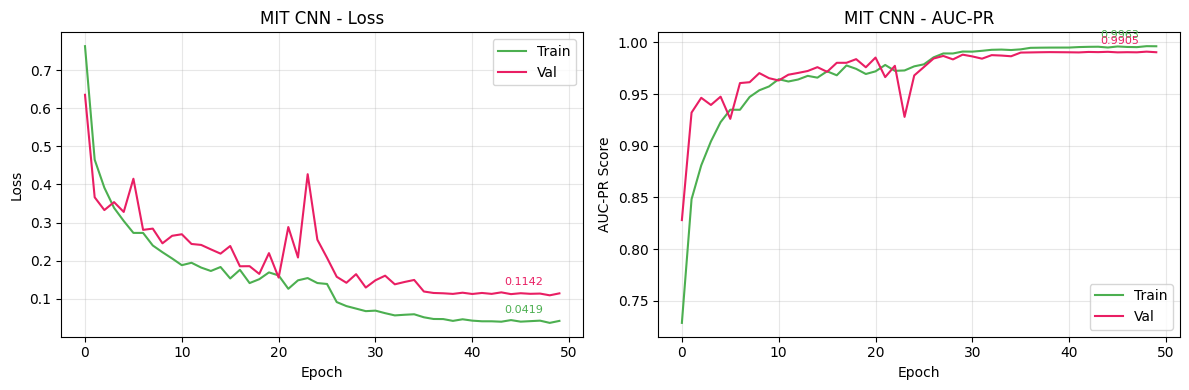

In [22]:
plot_training_curves(training_log_mit, 'MIT CNN')

<a id="sec-5-3"></a>
### 5.3 PTB Training

PTB validation AUC-PR was highly unstable through epoch 22 before stabilising after the first learning rate reduction at epoch 23, peaking at 0.9982. Training AUC-PR reached 1.0 from epoch 34, indicating overfitting. EarlyStopping triggered at epoch 36, restoring best weights from epoch 26.

In [23]:
"""
The PTB CNN is trained on the cluster-based split with class weights applied to penalise misclassification 
of the minority Normal class.
"""
# Train the PTB CNN
training_log_ptb = cnn_ptb.fit(
    X_ptb_train_cnn, y_ptb_train_c,        # training data and labels
    validation_data=(X_ptb_val_cnn, y_ptb_val_c), # cluster-based validation set
    epochs=50,     
    batch_size=64,
    class_weight=ptb_class_weight_dict,     # apply class weights to handle imbalance
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - auc_pr: 0.5588 - loss: 0.8693 - precision: 0.4863 - recall: 0.7605 - val_auc_pr: 0.3868 - val_loss: 0.8365 - val_precision: 0.3787 - val_recall: 0.1866 - learning_rate: 0.0010
Epoch 2/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc_pr: 0.8798 - loss: 0.5290 - precision: 0.7071 - recall: 0.9030 - val_auc_pr: 0.3931 - val_loss: 1.0969 - val_precision: 0.0250 - val_recall: 0.0018 - learning_rate: 0.0010
Epoch 3/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc_pr: 0.9486 - loss: 0.4099 - precision: 0.8034 - recall: 0.9356 - val_auc_pr: 0.6664 - val_loss: 0.5839 - val_precision: 0.6684 - val_recall: 0.7011 - learning_rate: 0.0010
Epoch 4/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc_pr: 0.9548 - loss: 0.3643 - precision: 0.8343 - recall: 0.9500 - val_auc_pr: 0.6908 - val_loss: 0.6218 - val_precision: 0.6919 - val_recall: 0.6630 - learning_rate: 0.0010
Epoch 5/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc_pr: 0.9750 - loss: 0

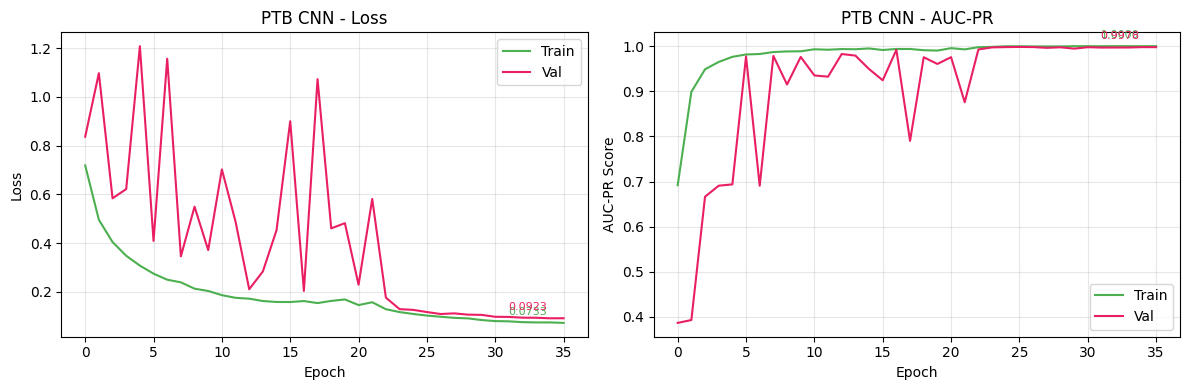

In [24]:
plot_training_curves(training_log_ptb, 'PTB CNN')

<a id="sec-5-4"></a>
### 5.4 CNN Hyperparameter Tuning 
Manual tuning across dropout, learning rate, and batch size found that dropout=0.3 (lr=0.001, batch_size=64) outperformed the base configuration, achieving a combined AUC-PR of 0.9957.


Testing: {'dropout_rate': 0.5, 'learning_rate': 0.001, 'batch_size': 64}

Testing: {'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 64}

Testing: {'dropout_rate': 0.4, 'learning_rate': 0.001, 'batch_size': 64}

Testing: {'dropout_rate': 0.5, 'learning_rate': 0.0005, 'batch_size': 64}

Testing: {'dropout_rate': 0.5, 'learning_rate': 0.001, 'batch_size': 32}

Tuning complete. Results saved.

Top Performing Configurations:
   dropout      lr  batch_size  MIT val_loss  MIT val_auc_pr  PTB val_loss  \
1      0.3  0.0010          64        0.0847          0.9925        0.0710   
3      0.5  0.0005          64        0.0938          0.9918        0.0884   
2      0.4  0.0010          64        0.0917          0.9929        0.0948   
4      0.5  0.0010          32        0.1137          0.9903        0.0787   
0      0.5  0.0010          64        0.1094          0.9905        0.1154   

   PTB val_auc_pr  Combined_Score  
1          0.9989         0.99570  
3          0.9993      

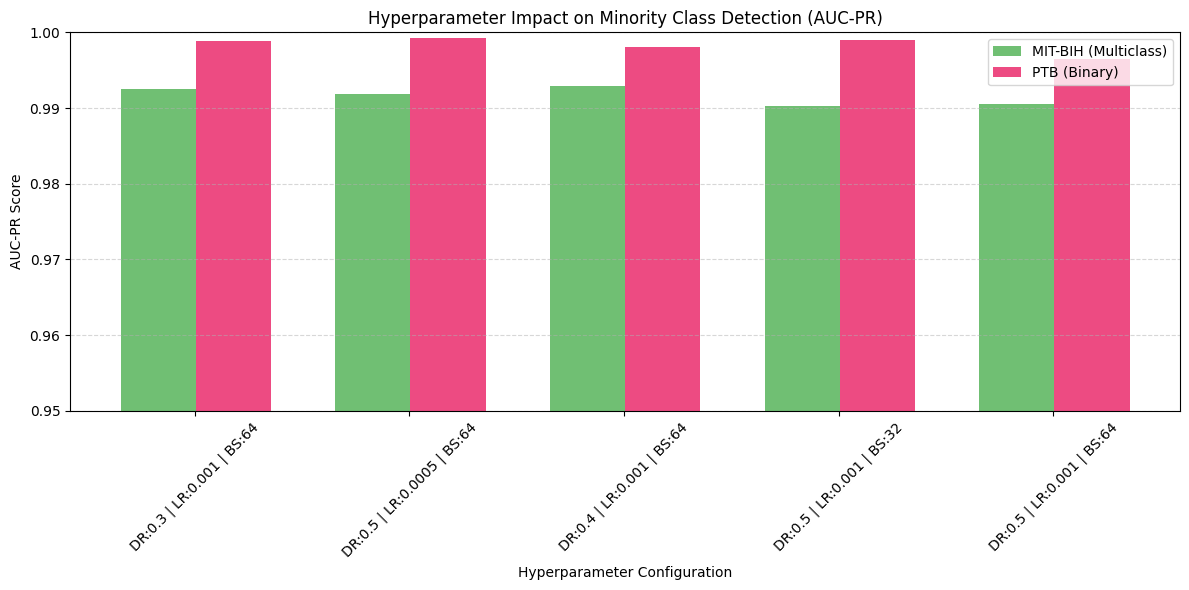

In [25]:
# my laptop
# if os.path.exists('tuning_results.csv'):
#     tuning_df = pd.read_csv('tuning_results.csv')
#     print('Loaded saved tuning results.')
# else:
# Kaggle
if os.path.exists('/kaggle/working/tuning_results.csv'):
    tuning_df = pd.read_csv('/kaggle/working/tuning_results.csv')
    print('Loaded saved tuning results.')
else:
        # Hyperparameter configurations to test
        configs = [
            {'dropout_rate': 0.5, 'learning_rate': 0.001, 'batch_size': 64},  # base configuration
            {'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 64},
            {'dropout_rate': 0.4, 'learning_rate': 0.001, 'batch_size': 64},
            {'dropout_rate': 0.5, 'learning_rate': 0.0005, 'batch_size': 64},
            {'dropout_rate': 0.5, 'learning_rate': 0.001, 'batch_size': 32},
        ]

        tuning_results = []

        for cfg in configs:
            print(f"\nTesting: {cfg}")

            # MIT-BIH (Multiclass)
            m_mit = build_1d_cnn_multiclass((187, 1), 5,
                                             dropout_rate=cfg['dropout_rate'],
                                             learning_rate=cfg['learning_rate'])
            log_mit = m_mit.fit(
                X_mit_train_cnn, y_mit_train_oh,
                validation_data=(X_mit_val_cnn, y_mit_val_oh),
                epochs=50, batch_size=cfg['batch_size'],
                class_weight=mit_class_weight_dict,
                callbacks=callbacks, verbose=0
            )
            
            # Identify peak performance for the minority classes
            best_val_loss_mit   = min(log_mit.history['val_loss'])
            best_val_auc_pr_mit = max(log_mit.history['val_auc_pr'])

            # PTB (Binary)
            m_ptb = build_1d_cnn_binary(dropout_rate=cfg['dropout_rate'],
                                          learning_rate=cfg['learning_rate'])
            log_ptb = m_ptb.fit(
                X_ptb_train_cnn, y_ptb_train_c,
                validation_data=(X_ptb_val_cnn, y_ptb_val_c),
                epochs=50, batch_size=cfg['batch_size'],
                class_weight=ptb_class_weight_dict,
                callbacks=callbacks, verbose=0
            )
            best_val_loss_ptb   = min(log_ptb.history['val_loss'])
            best_val_auc_pr_ptb = max(log_ptb.history['val_auc_pr'])

            tuning_results.append({
            'dropout': cfg['dropout_rate'],
            'lr': cfg['learning_rate'],
            'batch_size': cfg['batch_size'],
            'MIT val_loss': round(best_val_loss_mit, 4),
            'MIT val_auc_pr': round(best_val_auc_pr_mit, 4), # Primary metric for imbalanced MIT-BIH
            'PTB val_loss': round(best_val_loss_ptb, 4),
            'PTB val_auc_pr': round(best_val_auc_pr_ptb, 4), # Primary metric for imbalanced PTB
            })
            
        tuning_df = pd.DataFrame(tuning_results)    
        tuning_df.to_csv('/kaggle/working/tuning_results.csv', index=False)
        #tuning_df.to_csv('tuning_results.csv', index=False)
        print('\nTuning complete. Results saved.')
        
# Calculate a balanced score across both datasets
tuning_df['Combined_Score'] = (tuning_df['MIT val_auc_pr'] + tuning_df['PTB val_auc_pr']) / 2
tuning_df = tuning_df.sort_values(by='Combined_Score', ascending=False)

# Top performer
print("\nTop Performing Configurations:")
print(tuning_df.head())
print("\nBest Overall Configuration:")
print(tuning_df.iloc[0])

# Plot the comparison
plt.figure(figsize=(12, 6))
labels = [f"DR:{r['dropout']} | LR:{r['lr']} | BS:{int(r['batch_size'])}" for _, r in tuning_df.iterrows()]
x = range(len(tuning_df))

plt.bar(x, tuning_df['MIT val_auc_pr'], width=0.35, label='MIT-BIH (Multiclass)', alpha=0.8, color=colors[0])
plt.bar([i + 0.35 for i in x], tuning_df['PTB val_auc_pr'], width=0.35, label='PTB (Binary)', alpha=0.8, color=colors[1])

plt.xlabel('Hyperparameter Configuration')
plt.ylabel('AUC-PR Score')
plt.title('Hyperparameter Impact on Minority Class Detection (AUC-PR)')
plt.xticks([i + 0.17 for i in x], labels, rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0.95, 1.0)
plt.tight_layout()
plt.show()

In [26]:
# Retrain final CNN models using the best configuration from tuning 
best_cfg = tuning_df.iloc[0]
best_dropout    = best_cfg['dropout']
best_lr         = best_cfg['lr']
best_batch_size = int(best_cfg['batch_size'])

# MIT
cnn_mit = build_1d_cnn_multiclass((187, 1), 5, dropout_rate= best_dropout, learning_rate= best_lr)
log_mit_final = cnn_mit.fit(
    X_mit_train_cnn, y_mit_train_oh,
    validation_data=(X_mit_val_cnn, y_mit_val_oh),
    epochs=50, batch_size= best_batch_size,
    class_weight=mit_class_weight_dict,
    callbacks=callbacks, verbose=1
)

# PTB
cnn_ptb = build_1d_cnn_binary(dropout_rate= best_dropout, learning_rate= best_lr)
log_ptb_final = cnn_ptb.fit(
    X_ptb_train_cnn, y_ptb_train_c,
    validation_data=(X_ptb_val_cnn, y_ptb_val_c),
    epochs=50, batch_size= best_batch_size,
    class_weight=ptb_class_weight_dict,
    callbacks=callbacks, verbose=1
)

print('Final CNN models trained with best configuration.')

Epoch 1/50
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - auc_pr: 0.6956 - loss: 0.9056 - precision: 0.6899 - recall: 0.5996 - val_auc_pr: 0.8747 - val_loss: 0.5852 - val_precision: 0.8329 - val_recall: 0.8100 - learning_rate: 0.0010
Epoch 2/50
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - auc_pr: 0.8758 - loss: 0.4037 - precision: 0.8344 - recall: 0.7720 - val_auc_pr: 0.8748 - val_loss: 0.5717 - val_precision: 0.8632 - val_recall: 0.8021 - learning_rate: 0.0010
Epoch 3/50
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - auc_pr: 0.9144 - loss: 0.3105 - precision: 0.8705 - recall: 0.8147 - val_auc_pr: 0.9144 - val_loss: 0.4585 - val_precision: 0.8681 - val_recall: 0.8103 - learning_rate: 0.0010
Epoch 4/50
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - auc_pr: 0.9421 - loss: 0.2610 - precision: 0.8971 - recall: 0.8557 - val_auc_pr: 0.9585 - val_loss: 0.2868 - val_precision: 0.9075 - val_recall: 0.8919 - learning_rate: 0.0010
Epoch 5/50
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - auc_pr: 0.9487 

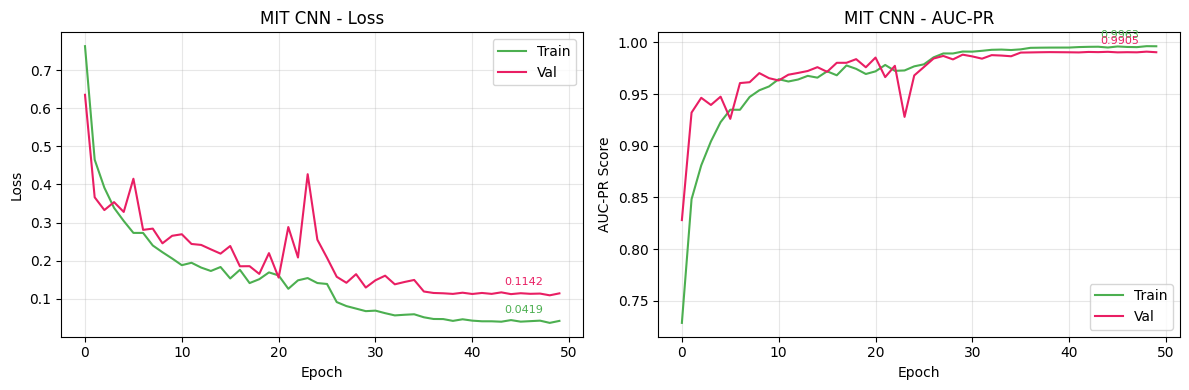

In [27]:
plot_training_curves(training_log_mit, 'MIT CNN')

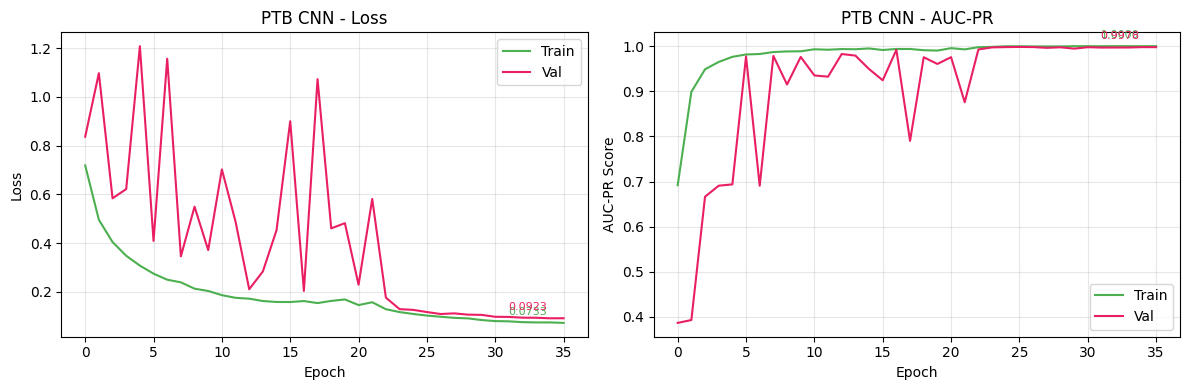

In [28]:
plot_training_curves(training_log_ptb, 'PTB CNN')

<a id="sec-5-5"></a>
### 5.5 Logistic Regression Tuning
C was tuned via 3-fold cross-validation. **MIT-BIH plateaued at C=10** (F1=0.4828); **PTB peaked at C=10** (F1=0.7788). **C=10** was selected **for both** tasks.

In [32]:

# Define the C values to test from very strict penalty (0.01) to very weak penalty (10)
for C in [0.01, 0.1, 1, 10, 100, 1000]:
    
    # Build Logistic Regression model with the current C value
    #  max_iter = 5000 instead of 1000 because 1000 was not enough for c=1000 on the large mit-data
    lr = LogisticRegression(C=C, max_iter=5000, tol=1e-4, class_weight='balanced', random_state=SEED)
    # 3-fold cross-validation: splits training data into 3 parts, trains on 2 and validates on 1, repeats 3 times
    # .mean() gives the average macro F1 score across the 3 folds
    # we use the macro f1 instead of plain f1 because both of datasets are imbanalced
    score = cross_val_score(lr, X_mit_train, y_mit_train, cv=3, scoring='f1_macro', n_jobs=-1).mean()
    # Print the result for this C value
    print(f'MIT  C={C}: val_acc={score:.4f}')

# Same process repeated for PTB
for C in [0.01, 0.1, 1, 10, 100, 1000]:
    lr = LogisticRegression(C=C, max_iter=1000, tol=1e-4, class_weight='balanced', random_state=SEED)
    score = cross_val_score(lr, X_ptb_train_c, y_ptb_train_c, cv=3, scoring='f1_macro', n_jobs=-1).mean()
    print(f'PTB  C={C}: val_acc={score:.4f}')

MIT  C=0.01: val_acc=0.4550
MIT  C=0.1: val_acc=0.4740
MIT  C=1: val_acc=0.4810
MIT  C=10: val_acc=0.4828
MIT  C=100: val_acc=0.4820
MIT  C=1000: val_acc=0.4821
PTB  C=0.01: val_acc=0.7288
PTB  C=0.1: val_acc=0.7553
PTB  C=1: val_acc=0.7713
PTB  C=10: val_acc=0.7788
PTB  C=100: val_acc=0.7773
PTB  C=1000: val_acc=0.7758


In [34]:
# Refit final models using the best C value found (C=10)
lr_mit = LogisticRegression(C=10, max_iter=1000, tol=1e-4, class_weight='balanced', random_state=SEED)
lr_mit.fit(X_mit_train, y_mit_train)

lr_ptb = LogisticRegression(C=10, max_iter=1000, tol=1e-4, class_weight='balanced', random_state=SEED)
lr_ptb.fit(X_ptb_train_c, y_ptb_train_c)

print('Both models trained with C=10.')

Both models trained with C=10.


<a id="sec-5-6"></a>
### 5.6 Random Forest Tuning
MIT-BIH plateaued at n=200 (F1=0.8649); PTB continued improving marginally to n=300 (F1=0.9554). n=200 selected for both as the gain at n=300 did not justify the cost.

In [35]:
# Tune n_estimators for MIT
for n in [50, 100, 200, 300]:
    rf = RandomForestClassifier(n_estimators=n, class_weight='balanced', random_state=SEED, n_jobs=-1)
    score = cross_val_score(rf, X_mit_train, y_mit_train, cv=3, scoring='f1_macro', n_jobs=-1).mean()
    print(f'MIT  n_estimators={n}: val_acc={score:.4f}')

# Tune n_estimators for PTB
for n in [50, 100, 200, 300]:
    rf = RandomForestClassifier(n_estimators=n, class_weight='balanced', random_state=SEED, n_jobs=-1)
    score = cross_val_score(rf, X_ptb_train_c, y_ptb_train_c, cv=3, scoring='f1_macro', n_jobs=-1).mean()
    print(f'PTB  n_estimators={n}: val_acc={score:.4f}')

MIT  n_estimators=50: val_acc=0.8618
MIT  n_estimators=100: val_acc=0.8632
MIT  n_estimators=200: val_acc=0.8649
MIT  n_estimators=300: val_acc=0.8650
PTB  n_estimators=50: val_acc=0.9511
PTB  n_estimators=100: val_acc=0.9529
PTB  n_estimators=200: val_acc=0.9550
PTB  n_estimators=300: val_acc=0.9554


In [36]:
rf_mit = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=SEED, n_jobs=-1)
rf_mit.fit(X_mit_train, y_mit_train)

rf_ptb = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=SEED, n_jobs=-1)
rf_ptb.fit(X_ptb_train_c, y_ptb_train_c)

print('Random Forest final models trained with n_estimators=200.')

Random Forest final models trained with n_estimators=200.


<a id="sec-6"></a>
## 6. Evaluation and Comparison
Models were evaluated on precision, recall, F1-score, AUC-PR, confusion matrices, ROC curves, and AUC.


<a id="sec-6-1"></a>
### 6.1 Classification Reports

On MIT-BIH, **CNN** achieved strong minority-class **recall (F: 0.88, S: 0.84)** at the cost of lower **precision (F: 0.57, S: 0.73)**, an acceptable clinical trade-off. **Random Forest** favoured **precision over recall** for minority classes (F: 0.83/0.59, S: 0.97/0.58). **Logistic Regression** was the **weakest**, with very low precision across all minority classes. On PTB, **CNN** achieved **near-perfect performance** for both classes (Normal: 1.00, Abnormal: 0.99). **Random Forest** performed **well** (Normal: 0.99, Abnormal: 0.90) but **Logistic Regression** showed **poor** Normal recall (0.69) and low Abnormal precision (0.51). **CNN is the preferred model** for both tasks.

In [37]:
def print_report(title, report, labels):
    print(title)
    print(f"{'':>12} {'precision':>10} {'recall':>10} {'f1-score':>10} {'support':>10}")
    print()
    for label in labels:
        r = report[label]
        print(f"{label:>12} {r['precision']:>10.2f} {r['recall']:>10.2f} {r['f1-score']:>10.2f} {r['support']:>10.0f}")

In [38]:
# MIT-CNN predictions
# model.predict() outputs class probabilities; argmax returns the predicted class index
y_mit_pred_cnn = cnn_mit.predict(X_mit_test_cnn).argmax(axis=1)
y_mit_pred_lr  = lr_mit.predict(X_mit_test)
y_mit_pred_rf  = rf_mit.predict(X_mit_test)

mit_predictions = {
    'MIT - CNN':                 y_mit_pred_cnn,
    'MIT - Logistic Regression': y_mit_pred_lr,
    'MIT - Random Forest':       y_mit_pred_rf,
}

for title, y_pred in mit_predictions.items():
    report = classification_report(y_mit_test, y_pred, target_names=mit_labels, output_dict=True)
    print_report(title, report, mit_labels)

685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
MIT - CNN
              precision     recall   f1-score    support

           N       0.99       0.98       0.99      18118
           S       0.73       0.84       0.78        556
           V       0.94       0.96       0.95       1448
           F       0.57       0.88       0.69        162
           Q       0.98       0.99       0.99       1608
MIT - Logistic Regression
              precision     recall   f1-score    support

           N       0.97       0.65       0.78      18118
           S       0.15       0.66       0.24        556
           V       0.29       0.72       0.42       1448
           F       0.08       0.88       0.15        162
           Q       0.72       0.92       0.81       1608
MIT - Random Forest
              precision     recall   f1-score    support

           N       0.97       1.00       0.98      18118
           S       0.97       0.58       0.73        556
           V       0.99       0.86       0.92

In [39]:
# PTB-CNN outputs a probability per sample; threshold 0.5 converts to binary labels
# matching the original encoding: Normal=0, Abnormal=1
# .flatten() removes the extra output dimension (None,1) → (None,)
y_ptb_pred_cnn = (cnn_ptb.predict(X_ptb_test_cnn) > 0.5).astype(int).flatten()
y_ptb_pred_lr  = lr_ptb.predict(X_ptb_test_c)
y_ptb_pred_rf  = rf_ptb.predict(X_ptb_test_c)

ptb_predictions = {
    'PTB - CNN':                 y_ptb_pred_cnn,
    'PTB - Logistic Regression': y_ptb_pred_lr,
    'PTB - Random Forest':       y_ptb_pred_rf,
}

for title, y_pred in ptb_predictions.items():
    report = classification_report(y_ptb_test_c, y_pred, target_names=class_names_ptb, output_dict=True)
    print_report(title, report, class_names_ptb)

81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
PTB - CNN
              precision     recall   f1-score    support

      Normal       1.00       1.00       1.00       1871
    Abnormal       0.99       0.99       0.99        716
PTB - Logistic Regression
              precision     recall   f1-score    support

      Normal       0.92       0.69       0.79       1871
    Abnormal       0.51       0.85       0.64        716
PTB - Random Forest
              precision     recall   f1-score    support

      Normal       0.96       0.99       0.97       1871
    Abnormal       0.96       0.90       0.93        716


<a id="sec-6-2"></a>
### 6.2 Confusion Matrices

On **MIT-BIH, CNN** correctly identified **143/162 F beats** and **469/556 S beats**. **Random Forest** favoured the majority class, correctly identifying only **95/162 F** and **322/556 S** beats despite near-perfect N recall **(18101/18118)**. **Logistic Regression** showed widespread confusion, misclassifying **6,403 N beats** across other classes. On **PTB, CNN misclassified only 16 samples** total. **Random Forest** had **100 errors**, while **Logistic Regression misclassified 689 samples**, including **582 Normal beats predicted as Abnormal** and **107 Abnormal beats predicted as Normal**; the most clinically dangerous error.

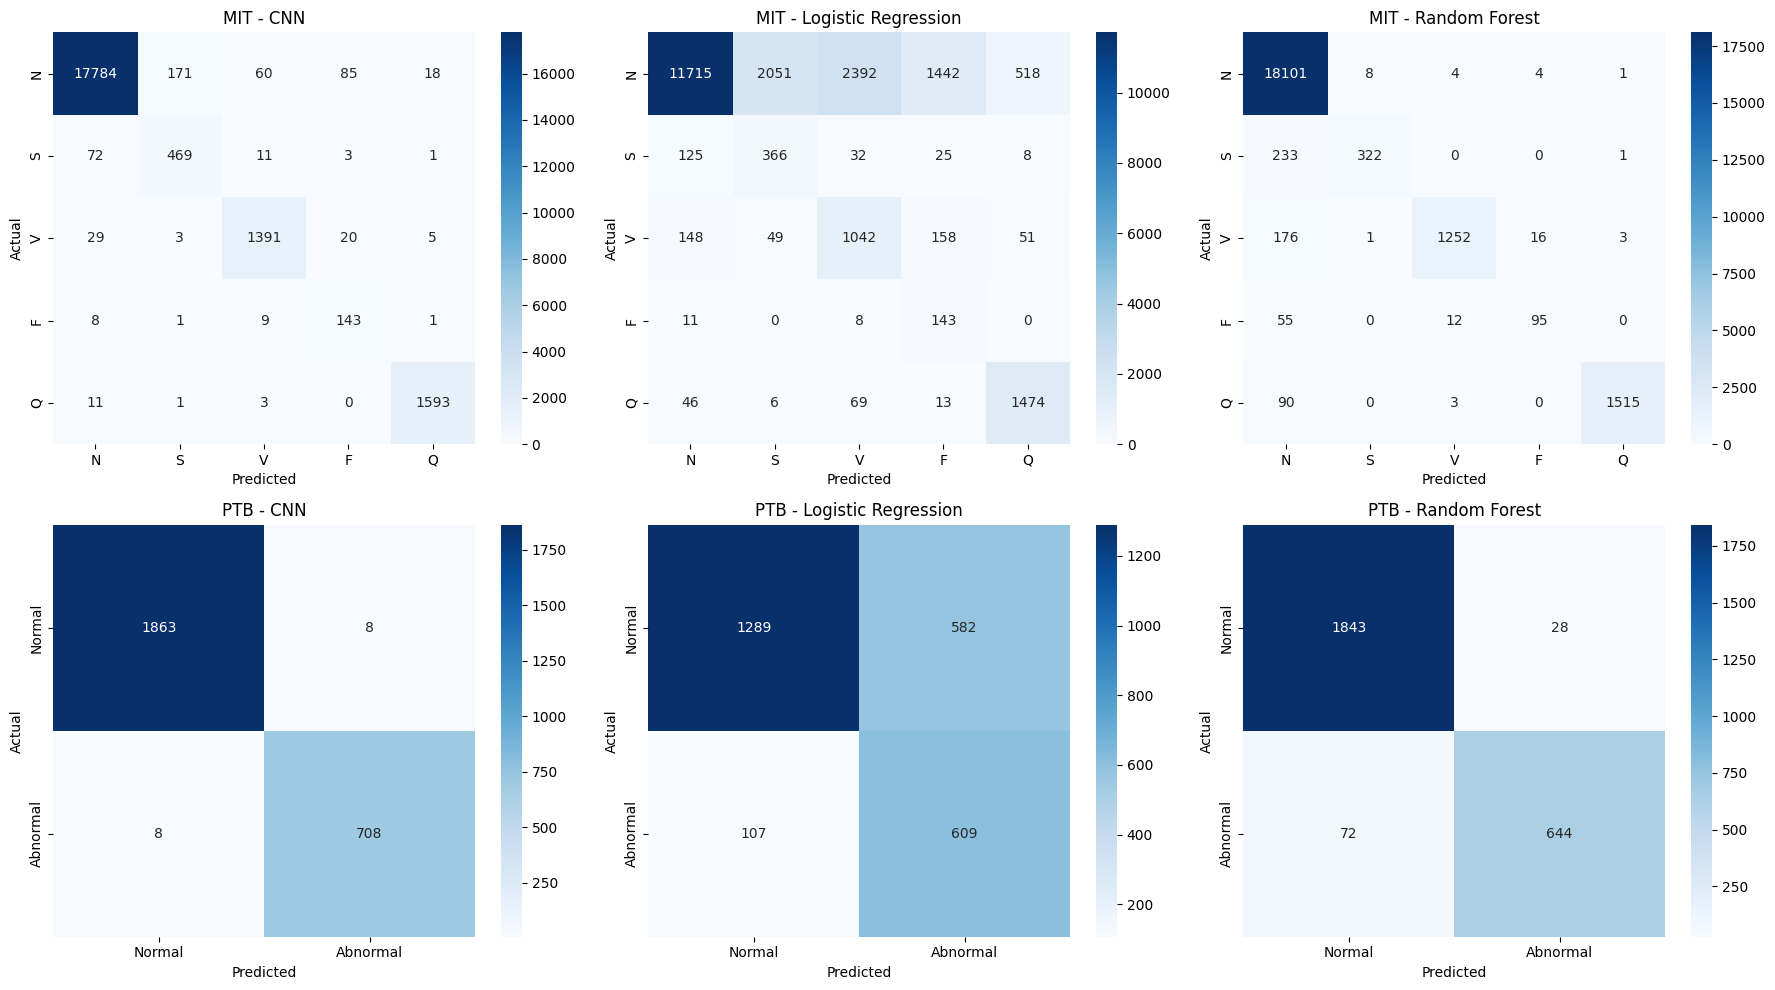

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# MIT-BIH confusion matrices
for ax, preds, title in zip(axes[0],
                             [y_mit_pred_cnn, y_mit_pred_lr, y_mit_pred_rf],
                             ['MIT - CNN', 'MIT - Logistic Regression', 'MIT - Random Forest']):
    cm = confusion_matrix(y_mit_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=mit_labels, yticklabels=mit_labels)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

# PTB confusion matrices
for ax, preds, title in zip(axes[1],
                             [y_ptb_pred_cnn, y_ptb_pred_lr, y_ptb_pred_rf],
                             ['PTB - CNN', 'PTB - Logistic Regression', 'PTB - Random Forest']):
    cm = confusion_matrix(y_ptb_test_c, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names_ptb, yticklabels=class_names_ptb)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

<a id="sec-6-3"></a>
### 6.3 ROC Curves and AUC
On **MIT-BIH, CNN (AUC=0.9905) and Random Forest (AUC=0.9906)** were near-identical, with both curves rising steeply and separating clearly from **Logistic Regression (AUC=0.9148)**. On **PTB, CNN achieved near-perfect AUC (0.9998)**, followed by **Random Forest (0.9918)** and **Logistic Regression (0.8339)**. Logistic Regression underperformed on both tasks, consistent with classification report findings.

685/685 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


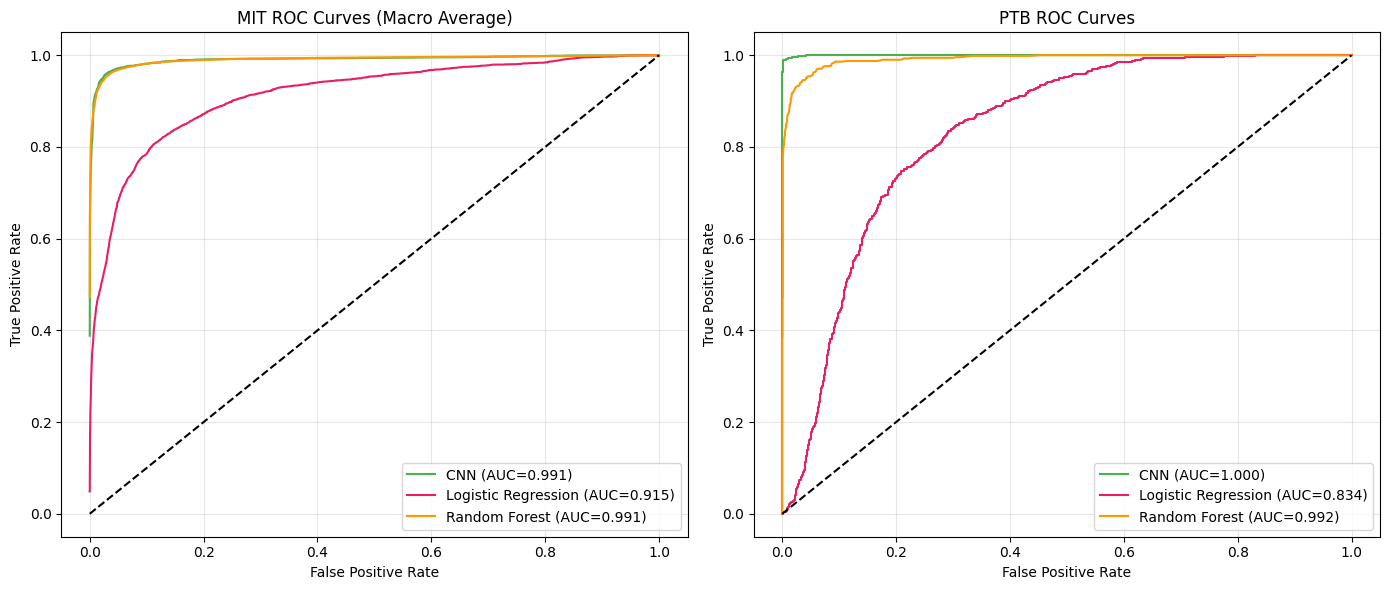

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# MIT 
classes = [0, 1, 2, 3, 4]
y_mit_test_bin = label_binarize(y_mit_test, classes=classes)

# CNN probabilities
y_mit_prob_cnn = cnn_mit.predict(X_mit_test_cnn)
# LR probabilities
y_mit_prob_lr  = lr_mit.predict_proba(X_mit_test)
# RF probabilities
y_mit_prob_rf  = rf_mit.predict_proba(X_mit_test)

for probs, label, color in zip(
        [y_mit_prob_cnn, y_mit_prob_lr, y_mit_prob_rf],
        ['CNN', 'Logistic Regression', 'Random Forest'],
        [colors[0], colors[1], colors[2]]):
    # macro-average ROC
    fpr, tpr, roc_auc = {}, {}, {}
    for i in classes:
        fpr[i], tpr[i], _ = roc_curve(y_mit_test_bin[:, i], probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    all_fpr = np.unique(np.concatenate([fpr[i] for i in classes]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in classes:
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= len(classes)
    macro_auc = auc(all_fpr, mean_tpr)
    axes[0].plot(all_fpr, mean_tpr, color=color, label=f'{label} (AUC={macro_auc:.3f})')

axes[0].plot([0,1],[0,1],'k--')
axes[0].set_title('MIT ROC Curves (Macro Average)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# PTB (binary) 
y_ptb_prob_cnn = cnn_ptb.predict(X_ptb_test_cnn).flatten()
y_ptb_prob_lr  = lr_ptb.predict_proba(X_ptb_test_c)[:, 1]
y_ptb_prob_rf  = rf_ptb.predict_proba(X_ptb_test_c)[:, 1]

for probs, label, color in zip(
        [y_ptb_prob_cnn, y_ptb_prob_lr, y_ptb_prob_rf],
        ['CNN', 'Logistic Regression', 'Random Forest'],
        [colors[0], colors[1], colors[2]]):
    fpr, tpr, _ = roc_curve(y_ptb_test_c, probs)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=color, label=f'{label} (AUC={roc_auc:.3f})')

axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('PTB ROC Curves')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()

<a id="sec-6-4"></a>
### 6.4 Summary Comparison Table
Across both tasks, the CNN consistently outperformed the baselines on Macro F1 and AUC-PR, confirming that temporal feature learning is essential for ECG classification. Random Forest was a competitive second, while Logistic Regression struggled on both tasks, particularly on AUC-PR, indicating that linear decision boundaries are insufficient for this problem.

In [42]:
def get_metrics(y_true, y_pred, y_prob, multiclass=True):
    macro_f1    = f1_score(y_true, y_pred, average='macro')
    weighted_f1 = f1_score(y_true, y_pred, average='weighted')
    if multiclass:
        auc_score   = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
        aucpr_score = average_precision_score(y_true, y_prob, average='macro')
    else:
        auc_score   = roc_auc_score(y_true, y_prob)
        aucpr_score = average_precision_score(y_true, y_prob)
    return round(macro_f1, 4), round(weighted_f1, 4), round(auc_score, 4), round(aucpr_score, 4)

In [43]:

# MIT
mit_cnn_metrics = get_metrics(y_mit_test, y_mit_pred_cnn, y_mit_prob_cnn)
mit_lr_metrics  = get_metrics(y_mit_test, y_mit_pred_lr,  y_mit_prob_lr)
mit_rf_metrics  = get_metrics(y_mit_test, y_mit_pred_rf,  y_mit_prob_rf)

# PTB
ptb_cnn_metrics = get_metrics(y_ptb_test_c, y_ptb_pred_cnn, y_ptb_prob_cnn, multiclass=False)
ptb_lr_metrics  = get_metrics(y_ptb_test_c, y_ptb_pred_lr,  y_ptb_prob_lr,  multiclass=False)
ptb_rf_metrics  = get_metrics(y_ptb_test_c, y_ptb_pred_rf,  y_ptb_prob_rf,  multiclass=False)

summary = pd.DataFrame([
    ['MIT', 'CNN',                 *mit_cnn_metrics],
    ['MIT', 'Logistic Regression', *mit_lr_metrics],
    ['MIT', 'Random Forest',       *mit_rf_metrics],
    ['PTB', 'CNN',                 *ptb_cnn_metrics],
    ['PTB', 'Logistic Regression', *ptb_lr_metrics],
    ['PTB', 'Random Forest',       *ptb_rf_metrics],
], columns=['Task', 'Model', 'Macro F1', 'Weighted F1', 'AUC', 'AUC-PR'])
summary = summary.set_index(['Task', 'Model'])
summary = summary.groupby('Task', group_keys=False).apply(
    lambda x: x.sort_values('AUC-PR', ascending=False)
)
summary

Macro F1  Weighted F1     AUC  AUC-PR
Task Model                                                     
MIT  CNN                    0.8801       0.9777  0.9905  0.9439
     Random Forest          0.8572       0.9703  0.9906  0.9225
     Logistic Regression    0.4778       0.7369  0.9148  0.5919
PTB  CNN                    0.9923       0.9938  0.9998  0.9995
     Random Forest          0.9508       0.9610  0.9918  0.9818
     Logistic Regression    0.7139       0.7475  0.8339  0.5540

<a id="sec-7"></a>
## 7. Critical Evaluation and Reflection
<a id="sec-7-1"></a>
### 7.1 Strengths and Limitations
The 1D CNN was the strongest model across both tasks, with strong minority-class recall on MIT-BIH (F: 0.88, S: 0.84) and high PTB recall, though the latter should be interpreted cautiously given overfitting signs. Logistic Regression and Random Forest baselines confirmed that non-linear temporal modelling is necessary. EarlyStopping prevented further overfitting by halting PTB training at epoch-36, restoring best weights from epoch 26.

The cluster-based PTB split is a meaningful methodological contribution. With no patient IDs available, a random split risks placing beats from the same patient in both train and test sets. MiniBatchKMeans with 290 clusters (matching the known patient count) combined with GroupShuffleSplit and a 200-seed search produced a well-calibrated 68.6/13.6/17.8 split with a 0.3% class balance gap, explicitly separating clusters across all sets and reducing leakage risk that the Kaggle split does not guard against.

Evaluation used Precision, Recall, F1-score, Confusion matrices, ROC-AUC, and AUC-PR. AUC-PR is the primary metric as it focuses on minority class performance and is not inflated by true negatives. ROC-AUC is retained for comparability but is known to overestimate performance under class imbalance. Together, these metrics capture both probability ranking quality and per-class classification performance across both tasks.

Despite these strengths, several limitations must be acknowledged. Class weights ranged from 0.24 (Normal) to 27.31 (Fusion) in MIT-BIH; such extreme weights reduced precision on rare classes, visible in Class F's precision of 0.57 despite recall of 0.88. Excluding synthetic oversampling preserves clinical data integrity, but weighting alone cannot fully eliminate false positives on rare classes with limited training examples. The three-block CNN architecture was chosen manually with no experiment comparing alternative depths or filter sizes, and despite L2 regularisation and SpatialDropout, the PTB model shows residual overfitting (train AUC-PR 1.0000 vs val 0.9982), likely due to model over-capacity for a binary task on a small dataset.

Baseline tuning was limited in scope. For Logistic Regression, only the regularisation strength C was tuned; solver and tolerance were left at defaults. For Random Forest, only four n_estimators values were tested, and max_depth, min_samples_split, and max_features were not tuned. Both models used 3-fold cross-validation, which is less reliable than 5 or 10-fold on imbalanced data, and class_weight='balanced' assumes equal misclassification cost, which does not reflect clinical priorities where missing an abnormal beat carries greater risk than a false alarm.

The CNN provides no explanation of which signal regions drive predictions. Clinicians require justification for automated outputs (Reyes et al., 2020), and the current evaluation cannot determine whether the model responds to genuine waveform features or preprocessing artefacts. Finally, both datasets are preprocessed benchmarks; segmentation, resampling, and normalisation were handled by Kachuee et al. (2018) before reaching this notebook, and performance on raw clinical recordings may be substantially lower.

<a id="sec-7-2"></a>
### 7.2 Challenges Encountered
The most significant challenge was identifying and resolving data leakage risk in the PTB split. An initial random split was discarded after recognising that beats from the same patient could appear in both train and test sets, requiring the cluster-based approach. A further complication was discovered in the PTB CSV files, where labels were inverted relative to the actual class distribution, requiring explicit label flipping before training. PTB training instability was persistent, with validation AUC-PR oscillating between 0.39 and 0.98 through epoch 22, addressed by adding L2 regularisation, SpatialDropout, and reducing the dense head from 128 to 64 neurons. Class F remained difficult despite the highest class weight (27.31), achieving only 0.57 precision due to its structural ambiguity between N and V beats. MIT-BIH training froze mid-epoch due to RAM constraints, requiring migration to Kaggle with GPU acceleration.

<a id="sec-7-3"></a>
### 7.3 Proposed Improvements
Incorporating true patient IDs into the PTB split would eliminate clustering as a proxy. A loss function that adjusts penalties based on prediction confidence would better handle rare classes than fixed class weights. Replacing manual tuning with Optuna would capture parameter interactions missed by one-at-a-time search. Adding a mechanism to highlight which timesteps drive predictions would enable clinical validation of whether the model responds to genuine waveform features or preprocessing artefacts. Finally, evaluation on raw PhysioNet recordings would provide a more realistic assessment of deployment readiness.

<a id="sec-8"></a>
## 8. Conclusion
This notebook addressed two ECG classification tasks using a 1D CNN, Logistic Regression, and Random Forest. The CNN achieved strong minority-class recall on MIT-BIH (F: 0.88, S: 0.84, AUC-PR: 0.9439) and near-perfect PTB classification performance (AUC-PR: 0.9995), though the latter shows signs of overfitting on a small dataset. The cluster-based split, label correction, and class weighting were key methodological contributions. Remaining limitations including CNN interpretability, PTB overfitting, and evaluation on preprocessed data only represent clear directions for future work.

<a id="sec-9"></a>
## 9. References
Kachuee et al. (2018) Kachuee, M., Fazeli, S., Sarrafzadeh, M. and Emami, M. (2018) 'ECG heartbeat classification: a deep transferable representation', Proceedings of the IEEE International Conference on Healthcare Informatics (ICHI), pp. 443–444. Available at: https://doi.org/10.48550/arXiv.1805.00794  

Reyes et al. (2020) Reyes, M., Meier, R., Pereira, S., Silva, C.A., Dahlweid, F.M., von Tengg-Kobligk, H., Summers, R.M. and Wiest, R. (2020) 'On the interpretability of artificial intelligence in radiology: challenges and opportunities', Radiology: Artificial Intelligence, 2(3), p.e190043. Available at: https://doi.org/10.1148/ryai.2020190043
